1. 这个多项式回归问题可以准确地解出吗？提示：使用线性代数。
1. 考虑多项式的模型选择。
    1. 绘制训练损失与模型复杂度（多项式的阶数）的关系图。观察到了什么？需要多少阶的多项式才能将训练损失减少到0?
    1. 在这种情况下绘制测试的损失图。
    1. 生成同样的图，作为数据量的函数。
1. 如果不对多项式特征$x^i$进行标准化($1/i!$)，会发生什么事情？能用其他方法解决这个问题吗？
1. 泛化误差可能为零吗？

In [8]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l
from d2l_utils import train_ch3, train_epoch_ch3, evaluate_accuracy, accuracy, predict_ch3,load_array,Animator

In [9]:
max_degree = 20  # 多项式的最大阶数
n_train, n_test = 100, 100  # 训练和测试数据集大小
true_w = np.zeros(max_degree)  # 分配大量的空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # gamma(n)=(n-1)!
# labels的维度:(n_train+n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

In [10]:
# NumPy ndarray转换为tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32) for x in [true_w, features, poly_features, labels]]

In [11]:
features[:2], poly_features[:2, :], labels[:2]

(tensor([[0.1789],
         [0.3283]]),
 tensor([[1.0000e+00, 1.7891e-01, 1.6005e-02, 9.5449e-04, 4.2692e-05, 1.5276e-06,
          4.5552e-08, 1.1643e-09, 2.6038e-11, 5.1761e-13, 9.2607e-15, 1.5062e-16,
          2.2457e-18, 3.0906e-20, 3.9497e-22, 4.7109e-24, 5.2678e-26, 5.5440e-28,
          5.5105e-30, 5.1889e-32],
         [1.0000e+00, 3.2828e-01, 5.3885e-02, 5.8966e-03, 4.8394e-04, 3.1774e-05,
          1.7385e-06, 8.1530e-08, 3.3456e-09, 1.2204e-10, 4.0062e-12, 1.1956e-13,
          3.2709e-15, 8.2598e-17, 1.9368e-18, 4.2389e-20, 8.6972e-22, 1.6795e-23,
          3.0631e-25, 5.2924e-27]]),
 tensor([4.9764, 5.3298]))

In [12]:
def evaluate_loss(net, data_iter, loss):  #@save
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2)  # 损失的总和,样本数量
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

In [13]:
def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    # 不设置偏置，因为我们已经在多项式中实现了它
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = load_array((train_features, train_labels.reshape(-1,1)),
                                batch_size)
    test_iter = load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

weight: [[ 5.014135   1.1827543 -3.400804   5.62767  ]]


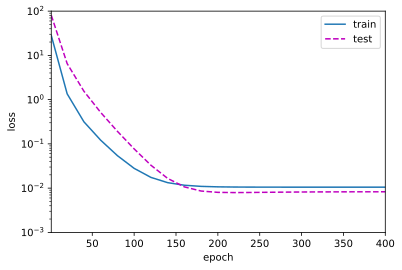

In [14]:
# 从多项式特征中选择前4个维度，即1,x,x^2/2!,x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

weight: [[2.9997704 4.23108  ]]


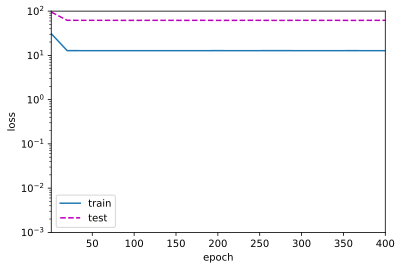

In [15]:
# 从多项式特征中选择前2个维度，即1和x
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

weight: [[ 5.026221    1.2898276  -3.4507198   5.076133    0.10476594  1.4856114
   0.15841043  0.2693651   0.0750374   0.01966726  0.17161418 -0.20420781
   0.13462038 -0.05511831 -0.19792056 -0.08747501  0.14888549  0.08942375
  -0.0868118   0.021865  ]]


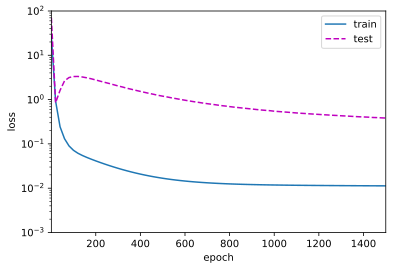

In [16]:
# 从多项式特征中选取所有维度
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:], num_epochs=1500)

第一问
可以，通过线性代数计算
将输入写作矩阵形式
y=Xw
最小二乘解w=(XTX)−1XTy

In [22]:
train_losses = []
test_losses = []

for degree in range(1, max_degree + 1):

    train_features = poly_features[:n_train, :degree]
    test_features = poly_features[n_train:, :degree]

    train_labels = labels[:n_train]
    test_labels = labels[n_train:]

    # 训练模型
    net = nn.Sequential(nn.Linear(degree, 1, bias=False))
    loss = nn.MSELoss()

    trainer = torch.optim.SGD(net.parameters(), lr=0.01)

    for epoch in range(200):
        trainer.zero_grad()
        l = loss(net(train_features), train_labels.reshape(-1,1))
        l.backward()
        trainer.step()

    train_loss = loss(net(train_features), train_labels.reshape(-1,1)).item()
    test_loss = loss(net(test_features), test_labels.reshape(-1,1)).item()
    
    test_losses.append(test_loss)
    train_losses.append(train_loss)

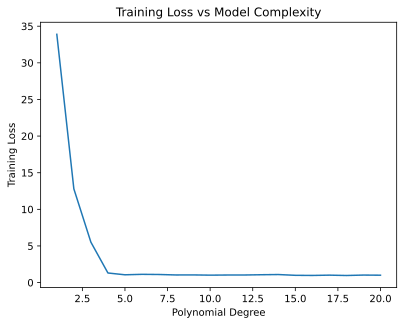

In [18]:
import matplotlib.pyplot as plt

plt.plot(range(1,max_degree+1), train_losses)
plt.xlabel("Polynomial Degree")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Model Complexity")
plt.show()

第二问A，随着多项式阶数增加，训练损失持续下降，当阶数达到真实模型阶数（3阶）后，损失已经接近0。

In [25]:
train_losses = []
test_losses = []

n_train = 20   # 训练样本少一点，更容易过拟合

for degree in range(1, poly_features.shape[1] + 1):

    train_features = poly_features[:n_train, :degree]
    test_features = poly_features[n_train:, :degree]

    train_labels = labels[:n_train]
    test_labels = labels[n_train:]

    # 训练模型
    net = nn.Sequential(nn.Linear(degree, 1, bias=False))
    loss = nn.MSELoss()

    trainer = torch.optim.SGD(net.parameters(), lr=0.01)

    for epoch in range(500):
        trainer.zero_grad()
        l = loss(net(train_features), train_labels.reshape(-1, 1))
        l.backward()
        trainer.step()

    train_loss = loss(net(train_features), train_labels.reshape(-1, 1)).item()
    test_loss = loss(net(test_features), test_labels.reshape(-1, 1)).item()

    test_losses.append(test_loss)
    train_losses.append(train_loss)

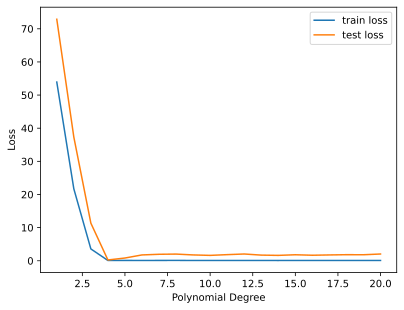

In [26]:
import matplotlib.pyplot as plt

plt.plot(range(1, poly_features.shape[1] + 1), train_losses, label="train loss")
plt.plot(range(1, poly_features.shape[1] + 1), test_losses, label="test loss")
plt.xlabel("Polynomial Degree")
plt.ylabel("Loss")
plt.legend()
plt.show()

第二问B
测试损失呈现先下降后上升的趋势，说明阶数过低会欠拟合，阶数过高会过拟合

In [29]:
data_sizes = [20,50,100]
degree = 10

train_losses = []
test_losses = []

for n in data_sizes:

    train_features = poly_features[:n, :degree]
    train_labels = labels[:n]

    test_features = poly_features[n_train:, :degree]
    test_labels = labels[n_train:]

    net = nn.Sequential(nn.Linear(degree,1,bias=False))
    loss = nn.MSELoss()
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)

    for epoch in range(200):
        trainer.zero_grad()
        l = loss(net(train_features), train_labels.reshape(-1,1))
        l.backward()
        trainer.step()

    train_loss = loss(net(train_features), train_labels.reshape(-1,1)).item()
    test_loss = loss(net(test_features), test_labels.reshape(-1, 1)).item()

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print("data size:",n,"train loss:",train_loss,"test loss:",test_loss)

data size: 20 train loss: 0.5532572269439697 test loss: 0.987480103969574
data size: 50 train loss: 1.1194541454315186 test loss: 1.4053311347961426
data size: 100 train loss: 0.9752010107040405 test loss: 0.915343701839447


训练数据量从 20 增加到 100 时，测试损失整体有所下降，且测试损失也整体降低，说明增加训练数据有助于提升模型的泛化能力。

问题三，高阶特征的数值会迅速变得非常大，导致不同特征的尺度差异很大，从而使梯度下降训练变得不稳定，甚至难以收敛。除了这种方法，还可以通过特征标准化、正则化或使用更稳定的优化算法来缓解这个问题。

问题四，误差通常不可能为零，真实数据包含噪声且训练数据有限不能完全学到数据分布